## Installation des packages

In [1]:
import subprocess
import sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "plotly",
]

def install (pack):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pack, "--quiet"])

for pack in packages:
    install(pack)

print("Package installes !")

Package installes !


**Justification des outils :**

- Pandas & Numpy : Standards pour la manipulation de données tabulaires massives.
- Scikit-Learn : Choisi pour sa robustesse, sa documentation et ses outils de validation (train_test_split, metrics).
- Random Forest vs Logistic Regression : Nous comparons un modèle linéaire (simple) à un modèle d'ensemble (complexe) pour tester si la non-linéarité des comportements d'achat justifie la puissance de calcul.

## Verifications

In [2]:
import os

fichiers_necessaires = [
    "datasets-project/datasets/orders.csv",
    "datasets-project/datasets/products.csv",
    "datasets-project/datasets/aisles.csv",
    "datasets-project/datasets/departments.csv",
    "datasets-project/datasets/order_products.csv",
]

for fichier in fichiers_necessaires:
    if os.path.exists(fichier):
        print(f"{fichier} trouve")
    else:
        print(f"{fichier} MANQUANT")

datasets-project/datasets/orders.csv trouve
datasets-project/datasets/products.csv trouve
datasets-project/datasets/aisles.csv trouve
datasets-project/datasets/departments.csv trouve
datasets-project/datasets/order_products.csv trouve


## Import des packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Imports OK !")

Imports OK !


## Preprocessing des donnees

**Chargement de donnees**

In [4]:

DATA_PATH = "datasets-project/datasets"

orders = pd.read_csv(os.path.join(DATA_PATH, "orders.csv"))
products = pd.read_csv(os.path.join(DATA_PATH, "products.csv"))
aisles = pd.read_csv(os.path.join(DATA_PATH, "aisles.csv"))
departments = pd.read_csv(os.path.join(DATA_PATH, "departments.csv"))
order_products = pd.read_csv(os.path.join(DATA_PATH, "order_products.csv"))

print("orders :", orders.shape)
print("products :", products.shape)
print("aisles :", aisles.shape)
print("departments :", departments.shape)
print("order_products :", order_products.shape)

orders : (1444444, 6)
products : (49688, 4)
aisles : (134, 2)
departments : (21, 2)
order_products : (13692886, 4)


**Exploration des fichiers**

In [5]:
print("ORDERS")
display(orders.head(3))
print(orders.dtypes)

print("\nPRODUCTS")
display(products.head(3))

print("\nAISLES")
display(aisles.head(3))

print("\nDEPARTEMENTS")
display(departments.head(3))

print("\nORDER_PRODUCTS")
display(order_products.head(3))

ORDERS


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1.0,1.0,2.0,8.0,NaN
1,2398795,1.0,2.0,3.0,7.0,15.0
2,473747,1.0,3.0,3.0,12.0,21.0


order_id                    int64
user_id                   float64
order_number              float64
order_dow                 float64
order_hour_of_day         float64
days_since_prior_order    float64
dtype: object

PRODUCTS


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7



AISLES


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars



DEPARTEMENTS


,department_id,department
0,1,frozen
1,2,other
2,3,bakery



ORDER_PRODUCTS


,order_id,product_id,add_to_cart_order,reordered
0,2,33120.0,1.0,1.0
1,2,28985.0,2.0,1.0
2,2,9327.0,3.0,0.0


**Correction des colonnes de orders**

In [6]:
orders = pd.read_csv(os.path.join(DATA_PATH, "orders.csv"))

orders = orders.rename(columns={
    "order_number"           : "order_dow",
    "order_dow"              : "order_hour_of_day", 
    "order_hour_of_day"      : "days_since_prior_order",
    "days_since_prior_order" : "order_number"
})

orders = orders.drop(columns=["order_number"])

print(orders.columns.tolist())
print(orders.head(3))
print("\nNaN par colonne :")
print(orders.isnull().sum())

['order_id', 'user_id', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
   order_id  user_id  order_dow  order_hour_of_day  days_since_prior_order
0   2539329      1.0        1.0                2.0                     8.0
1   2398795      1.0        2.0                3.0                     7.0
2    473747      1.0        3.0                3.0                    12.0

NaN par colonne :
order_id                   0
user_id                   31
order_dow                 23
order_hour_of_day         22
days_since_prior_order    23
dtype: int64


**Fusion**

In [7]:
df = order_products.merge(orders, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(aisles, on="aisle_id", how="left")
df = df.merge(departments, on="department_id", how="left")

print("Shape après fusion :", df.shape)

Shape après fusion : (13692886, 13)


## Nettoyage

In [8]:
# days_since_prior_order : NaN = première commande --> remplace par 0
df["days_since_prior_order"] = df["days_since_prior_order"].fillna(0)

#Supprimer les lignes avec NaN
df = df.dropna(subset=[
    "user_id",
    "order_dow",
    "order_hour_of_day",
    "product_name",
    "aisle",
    "department",
    "reordered",
    "add_to_cart_order",
    "aisle_id", 
    "department_id"
])

#Correction = float devient int
df["user_id"] = df["user_id"].astype(int)
df["order_dow"] = df["order_dow"].astype(int)
df["order_hour_of_day"] = df["order_hour_of_day"].astype(int)
df["days_since_prior_order"] = df["days_since_prior_order"].astype(int)
df["product_id"] = df["product_id"].astype(int)
df["reordered"] = df["reordered"].astype(int)
df["add_to_cart_order"] = df["add_to_cart_order"].astype(int)
df["aisle_id"] = df["aisle_id"].astype(int)
df["department_id"] = df["department_id"].astype(int)

df = df.drop(columns=["eval_set"], errors="ignore")

#Suppression des doublons
df = df.drop_duplicates()

**Verifications**

In [9]:
print("Shape final :", df.shape)
print("NaN restants :", df.isnull().sum().sum())
print("Doublons restants :", df.duplicated().sum())
print("\nTypes finaux :")
print(df.dtypes)
display(df.head(5))

Shape final : (13690738, 13)
NaN restants : 0
Doublons restants : 0

Types finaux :
order_id                  int64
product_id                int64
add_to_cart_order         int64
reordered                 int64
user_id                   int64
order_dow                 int64
order_hour_of_day         int64
days_since_prior_order    int64
product_name                str
aisle_id                  int64
department_id             int64
aisle                       str
department                  str
dtype: object


,order_id,product_id,add_to_cart_order,reordered,user_id,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,3,5,9,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,3,5,9,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,3,5,9,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,3,5,9,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,3,5,9,Natural Sweetener,17,13,baking ingredients,pantry


## EDA - Visualisation

**1. Bloc : Analyse de l'Assortiment et Performance**

### Q1 : Quels sont les 10 produits les plus vendus ("Top Sellers") et leur poids relatif dans le chiffre d'affaires total ?

Calcul

In [10]:
top_sellers = (
    df.groupby("product_name")
    .size()
    .reset_index(name="total_orders")
    .sort_values("total_orders", ascending=False)
    .head(10)
)

total_ventes = df.shape[0]
top_sellers["poids_relatif"] = (top_sellers["total_orders"] / total_ventes * 100).round(2)

print(top_sellers)

                 product_name  total_orders  poids_relatif
3625                   Banana        199620           1.46
3422   Bag of Organic Bananas        160602           1.17
31519    Organic Strawberries        111962           0.82
28461    Organic Baby Spinach        101905           0.74
29908    Organic Hass Avocado         90364           0.66
28425         Organic Avocado         74951           0.55
22115             Large Lemon         64855           0.47
42381            Strawberries         60757           0.44
23117                   Limes         59290           0.43
32073      Organic Whole Milk         58204           0.43


Visualisation

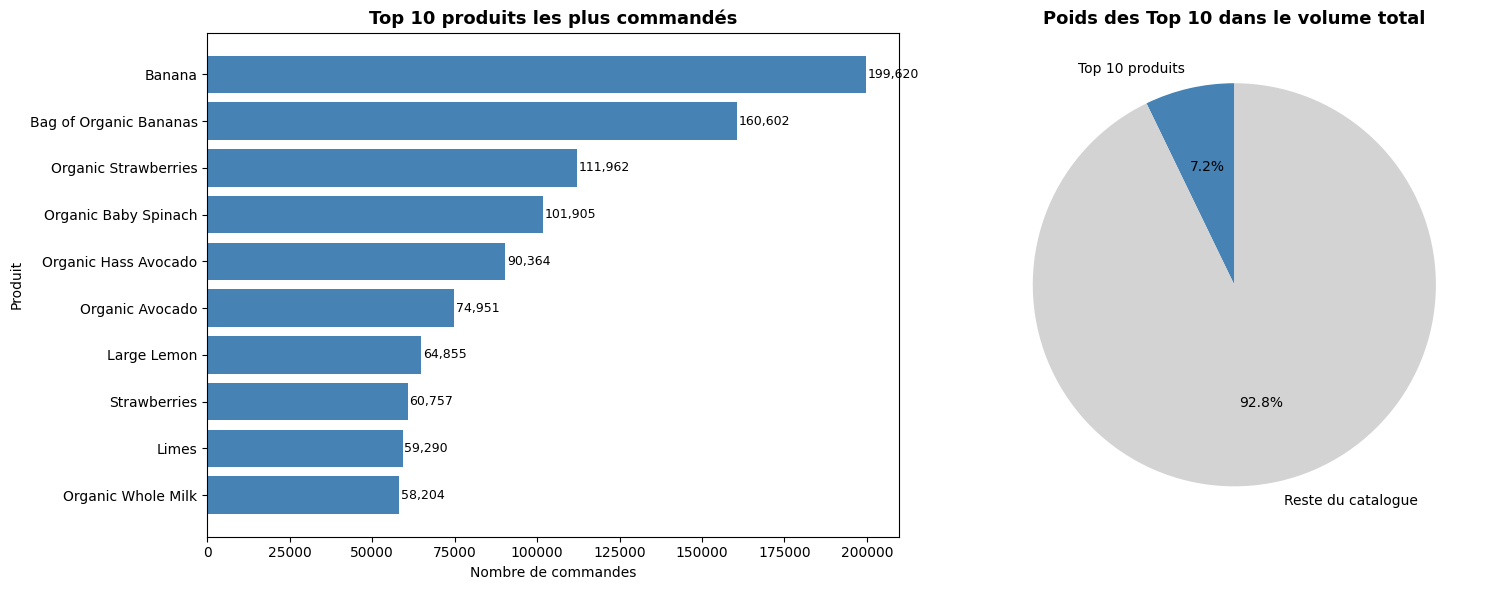

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Barplot: volume de ventes
axes[0].barh(
    top_sellers["product_name"][::-1],
    top_sellers["total_orders"][::-1],
    color="steelblue"
)
axes[0].set_title("Top 10 produits les plus commandés", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Nombre de commandes")
axes[0].set_ylabel("Produit")

for i, (val, name) in enumerate(zip(top_sellers["total_orders"][::-1], top_sellers["product_name"][::-1])):
    axes[0].text(val + 500, i, f"{val:,}", va="center", fontsize=9)

#Camembert : poids relatif du top 10 contre reste
top10_total = top_sellers["total_orders"].sum()
reste = total_ventes - top10_total

axes[1].pie(
    [top10_total, reste],
    labels=["Top 10 produits", "Reste du catalogue"],
    autopct="%1.1f%%",
    colors=["steelblue", "lightgrey"],
    startangle=90
)
axes[1].set_title("Poids des Top 10 dans le volume total", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

### Interprétation :

Les 10 produits les plus commandés représentent 7,2% du volume total des ventes.

La Banana est de loin le produit le plus commandé, ce qui suggère qu'elle doit
toujours être en stock et mise en avant dans l'interface.

**Action business :** Prioriser le réapprovisionnement et la visibilité de ces
10 produits clés pour maximiser les conversions.

### Q2 : Quels sont les rayons (aisles) qui présentent le plus fort taux de pénétration (présents dans le plus grand nombre de commandes) ?

Calcul

In [12]:
total_commandes = df["order_id"].nunique()

# Pour chaque rayon, compter combien de commandes il apparaît
penetration_aisles = (
    df.groupby("aisle")["order_id"]
    .nunique()
    .reset_index(name="nb_commandes")
    .sort_values("nb_commandes", ascending=False)
    .head(15)
)

# Taux en pourcentage
penetration_aisles["taux_penetration"] = (
    penetration_aisles["nb_commandes"] / total_commandes * 100
).round(2)

print(f"Nombre total de commandes : {total_commandes:,}")
print(penetration_aisles)

Nombre total de commandes : 1,357,467
                             aisle  nb_commandes  taux_penetration
50                    fresh fruits        756861             55.76
53                fresh vegetables        603368             44.45
98      packaged vegetables fruits        497821             36.67
133                         yogurt        357865             26.36
83                            milk        331529             24.42
93                 packaged cheese        312119             22.99
131  water seltzer sparkling water        258900             19.07
119                soy lactosefree        230036             16.95
25                  chips pretzels        226746             16.70
11                           bread        222050             16.36
41                            eggs        185792             13.69
110                   refrigerated        181499             13.37
62                  frozen produce        167087             12.31
32                      

Visualisation

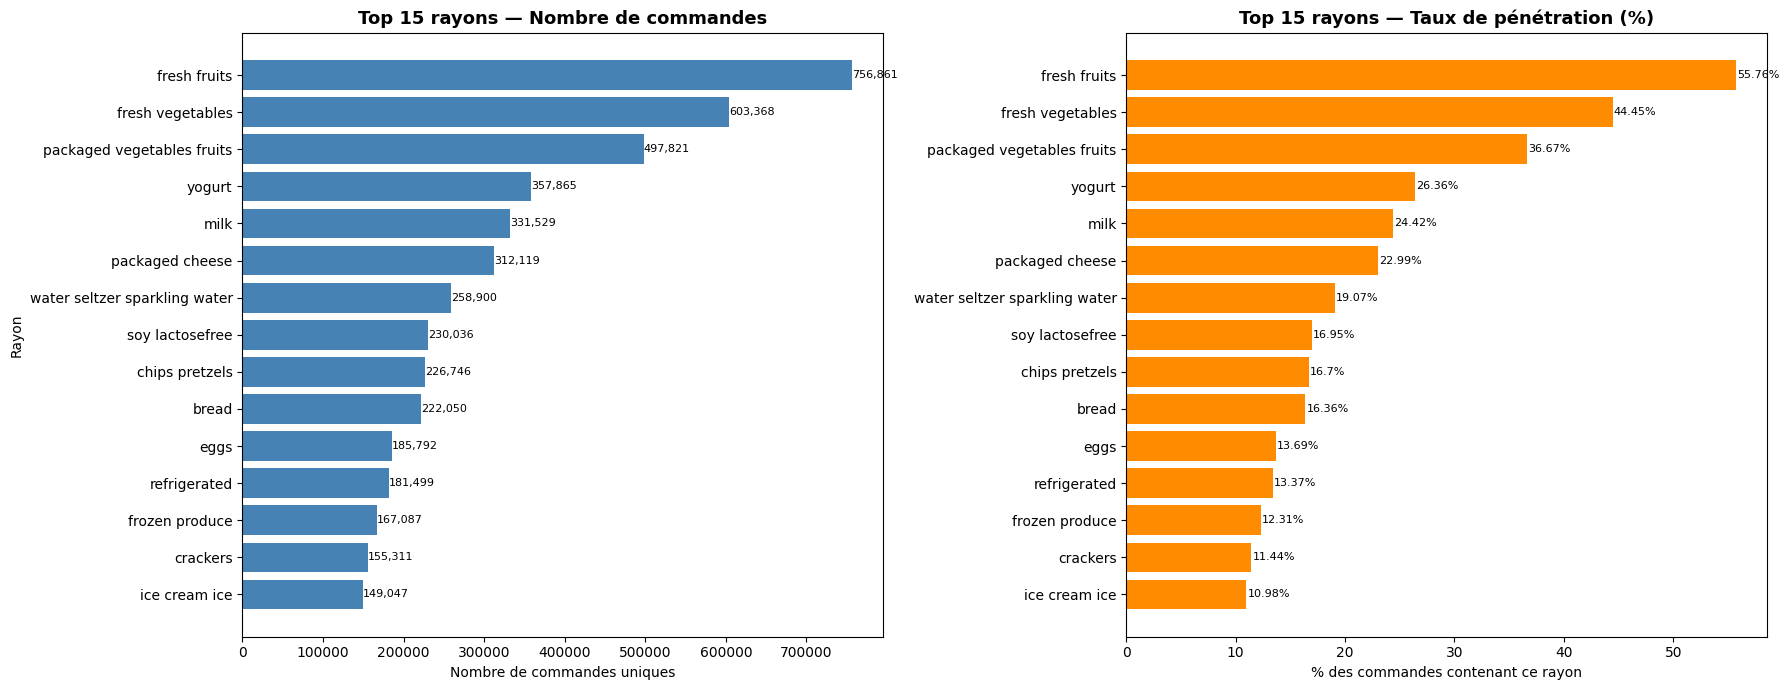

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#Barplot : nombre de commandes par rayon
colors = plt.cm.Blues_r(range(50, 200, 10))[:15]

axes[0].barh(
    penetration_aisles["aisle"][::-1],
    penetration_aisles["nb_commandes"][::-1],
    color="steelblue"
)
axes[0].set_title("Top 15 rayons — Nombre de commandes", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Nombre de commandes uniques")
axes[0].set_ylabel("Rayon")

for i, val in enumerate(penetration_aisles["nb_commandes"][::-1]):
    axes[0].text(val + 200, i, f"{val:,}", va="center", fontsize=8)

#Barplot : taux de pénétration en pourcentage
axes[1].barh(
    penetration_aisles["aisle"][::-1],
    penetration_aisles["taux_penetration"][::-1],
    color="darkorange"
)
axes[1].set_title("Top 15 rayons — Taux de pénétration (%)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("% des commandes contenant ce rayon")
axes[1].set_ylabel("")

for i, val in enumerate(penetration_aisles["taux_penetration"][::-1]):
    axes[1].text(val + 0.1, i, f"{val}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### Interpretation :

Le rayon "Fresh fruits" est présent dans 55,76% de toutes les commandes, ce qui en fait
le rayon le plus incontournable du catalogue. 

Les rayons "fresh fruits" et "fresh vegetables" dominent largement, confirmant que les produits frais sont
le moteur principal des achats en ligne.

**Action business :** Ces rayons à forte pénétration doivent être placés en
tête de l'interface utilisateur et bénéficier d'un stock prioritaire pour
éviter toute rupture qui ferait fuir les clients.

### Q3 : Quelle est la part de marché des produits labellisés "Organic" par rapport aux produits conventionnels dans chaque département ?

Calcul

In [14]:
#Détecter les produits "Organic" via le nom du produit
df["is_organic"] = df["product_name"].str.contains("Organic", case=False, na=False)
df["label"] = df["is_organic"].map({True: "Organic", False: "Conventionnel"})

#Compter les ventes par département et label
organic_dept = (
    df.groupby(["department", "label"])
    .size()
    .reset_index(name="nb_ventes")
)

# Calculer le pourcentage par département
organic_dept["pct"] = (
    organic_dept.groupby("department")["nb_ventes"]
    .transform(lambda x: x / x.sum() * 100)
).round(2)

# Extraire Organic par département
organic_only = (
    organic_dept[organic_dept["label"] == "Organic"]
    .sort_values("pct", ascending=False)
)

print(organic_only[["department", "nb_ventes", "pct"]].to_string())

         department  nb_ventes    pct
39          produce    2161091  53.96
13     canned goods     218282  48.43
11             bulk       7043  47.91
3            babies      77323  43.22
29          missing      12237  41.62
15       dairy eggs     719579  31.48
19  dry goods pasta     100760  27.56
33           pantry     179659  22.69
9         breakfast      61591  20.62
27     meat seafood      59929  20.05
21           frozen     186639  19.78
5            bakery      92888  18.70
17             deli      75382  16.99
41           snacks     206417  16.97
25    international      19057  16.82
7         beverages     141895  12.49
31            other        865   5.64
35    personal care       9629   5.11
37             pets        543   1.31
1           alcohol        251   0.38
23        household        105   0.03


Visualisation

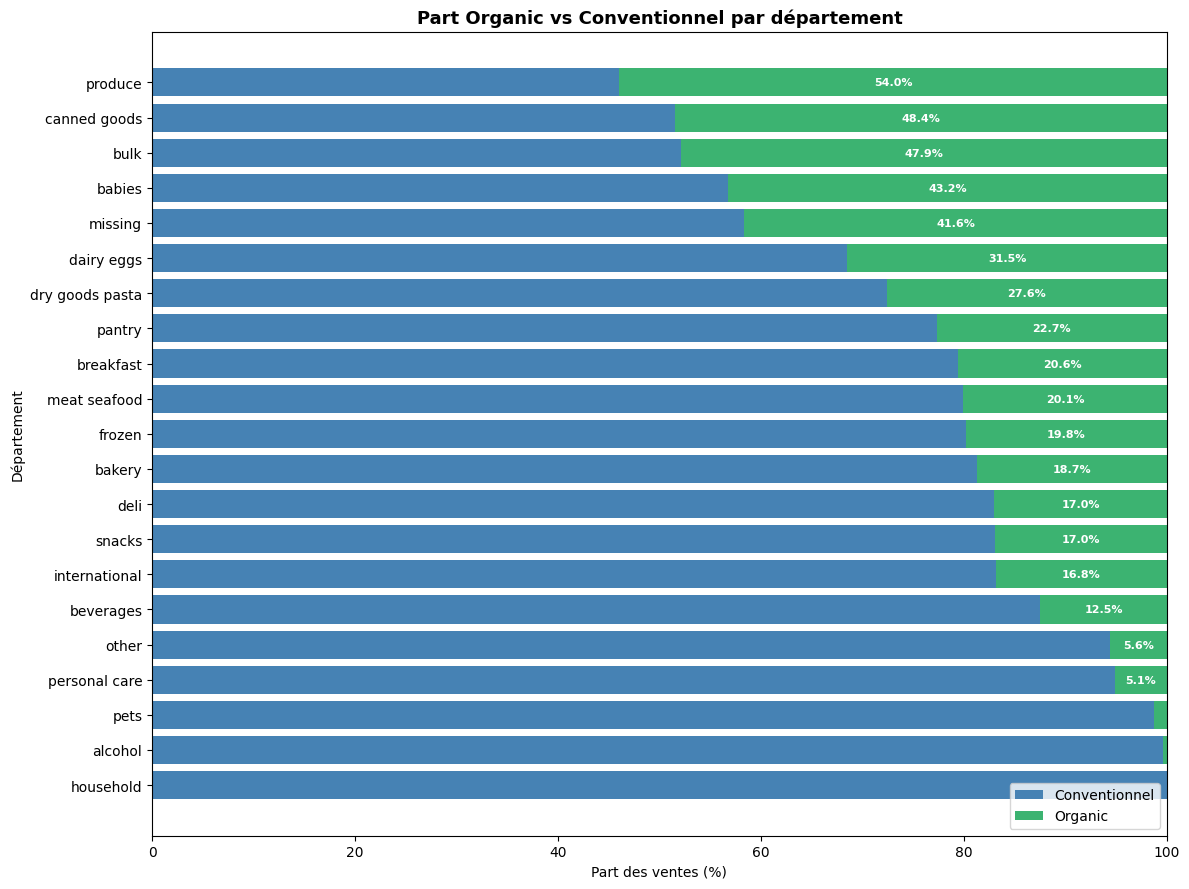

In [15]:
#Barplot
pivot = organic_dept.pivot_table(
    index="department",
    columns="label",
    values="pct",
    fill_value=0
).sort_values("Organic", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))

bars_conv = ax.barh(
    pivot.index,
    pivot["Conventionnel"],
    color="steelblue",
    label="Conventionnel"
)
bars_org = ax.barh(
    pivot.index,
    pivot["Organic"],
    left=pivot["Conventionnel"],
    color="mediumseagreen",
    label="Organic"
)

# Ajouter les % sur les barres Organic
for i, (org_val, conv_val) in enumerate(zip(pivot["Organic"], pivot["Conventionnel"])):
    if org_val > 5:
        ax.text(
            conv_val + org_val / 2, i,
            f"{org_val:.1f}%",
            va="center", ha="center",
            fontsize=8, color="white", fontweight="bold"
        )

ax.set_title("Part Organic vs Conventionnel par département", fontsize=13, fontweight="bold")
ax.set_xlabel("Part des ventes (%)")
ax.set_ylabel("Département")
ax.legend(loc="lower right")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

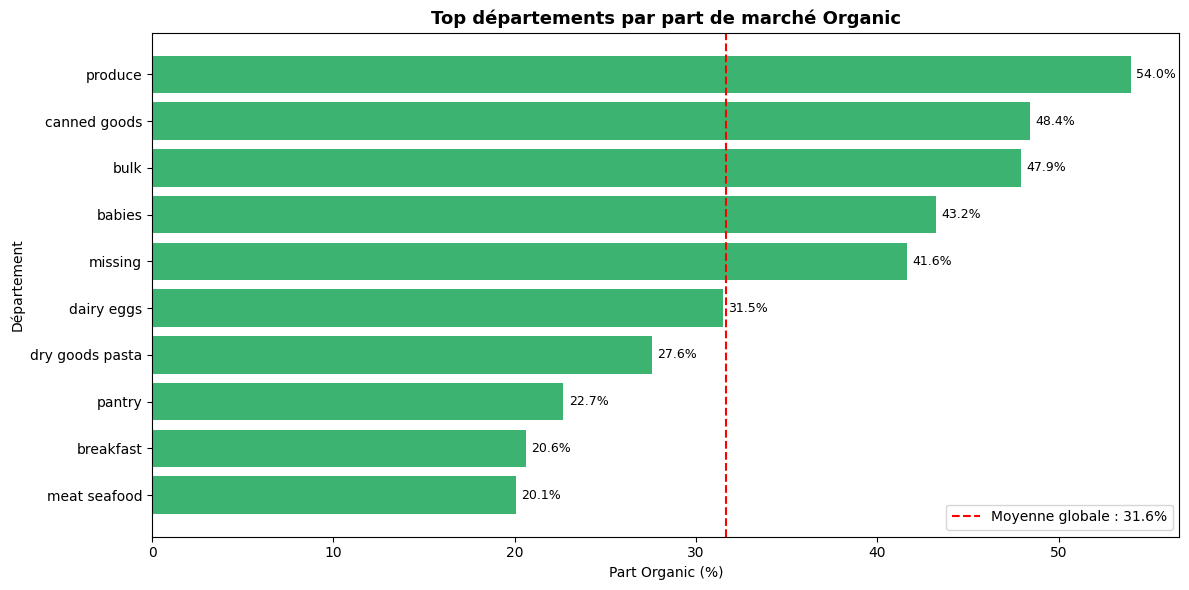

In [16]:
#Barplot Top départements Organic
top_organic = organic_only.head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(
    top_organic["department"][::-1],
    top_organic["pct"][::-1],
    color="mediumseagreen"
)

moyenne_organic = df["is_organic"].mean() * 100
plt.axvline(
    x=moyenne_organic,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Moyenne globale : {moyenne_organic:.1f}%"
)

for i, val in enumerate(top_organic["pct"][::-1]):
    plt.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)

plt.title("Top départements par part de marché Organic", fontsize=13, fontweight="bold")
plt.xlabel("Part Organic (%)")
plt.ylabel("Département")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation :

La moyenne globale de produits Organic est de 31,6%. Le département produce se 
démarque avec 54,0% de ventes Organic, bien au-dessus de la moyenne.

À l'inverse, les départements comme "pets" et "alcohol" ont une part Organic
quasi nulle, ce qui reflète la nature de leurs produits. 
Et le département "household" n'a pas de part Organic.

**Action business :** Les départements à forte demande Organic (produce, canned goods, bulk et babies et missing). Mettre en avant
un label "Organic" visible dans ces rayons peut augmenter le panier moyen.


**2. Bloc : Comportement Temporel des Consommateurs**

### Q4 : Existe-t-il un pic de commande spécifique durant la semaine ? (Analyse par order_dow - Day of Week).

Calcul

In [17]:
#Compter le nombre de commandes uniques par jour de semaine
commandes_par_jour = (
    df.groupby("order_dow")["order_id"]
    .nunique()
    .reset_index(name="nb_commandes")
)

jours = {0: "Dimanche", 1: "Lundi", 2: "Mardi", 3: "Mercredi",
         4: "Jeudi", 5: "Vendredi", 6: "Samedi"}
commandes_par_jour["jour"] = commandes_par_jour["order_dow"].map(jours)

#Pourcentage
commandes_par_jour["pct"] = (
    commandes_par_jour["nb_commandes"] / commandes_par_jour["nb_commandes"].sum() * 100
).round(2)

print(commandes_par_jour[["jour", "nb_commandes", "pct"]])

        jour  nb_commandes   pct
0      Lundi         86875  6.40
1      Mardi         87230  6.43
2   Mercredi         87293  6.43
3      Jeudi         76555  5.64
4   Vendredi         68805  5.07
..       ...           ...   ...
94       NaN           664  0.05
95       NaN           655  0.05
96       NaN           627  0.05
97       NaN           585  0.04
98       NaN           581  0.04

[99 rows x 3 columns]


Visualisation

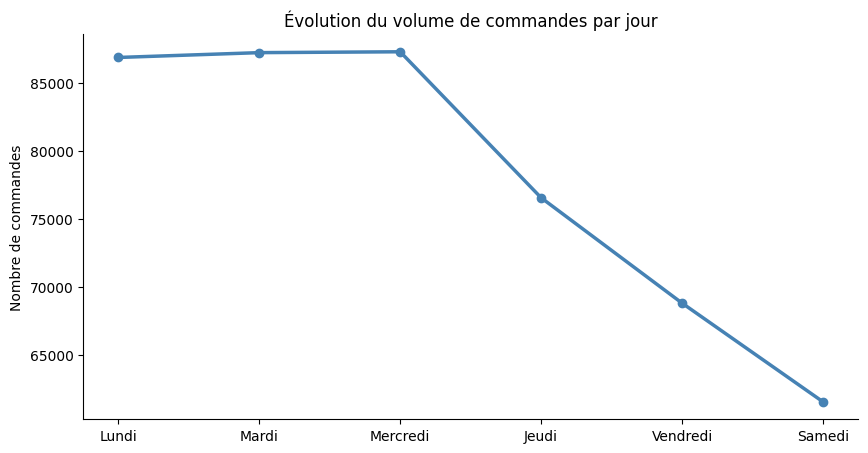

In [18]:
# 1. On s'assure de ne garder que les lignes où le mapping a fonctionné (jours 0-6)
# On filtre les NaN générés par le mapping
commandes_par_jour = (
    df.groupby(["order_dow"])["order_id"]
    .nunique()
    .reset_index(name="nb_commandes")
)

# Application du dictionnaire
jours = {0: "Dimanche", 1: "Lundi", 2: "Mardi", 3: "Mercredi", 4: "Jeudi", 5: "Vendredi", 6: "Samedi"}
commandes_par_jour["jour"] = commandes_par_jour["order_dow"].map(jours)

# ON SUPPRIME LES LIGNES HORS-PLAGE (0-6)
commandes_par_jour = commandes_par_jour.dropna(subset=['jour']).sort_values("order_dow")

# 2. Visualisation (Ce code ne plantera plus)
plt.figure(figsize=(10, 5))
plt.plot(
    commandes_par_jour["jour"], 
    commandes_par_jour["nb_commandes"], 
    marker="o", 
    linewidth=2.5, 
    color="steelblue"
)
plt.title("Évolution du volume de commandes par jour")
plt.ylabel("Nombre de commandes")
sns.despine() # Pour le style Tufte (épuration)
plt.show()

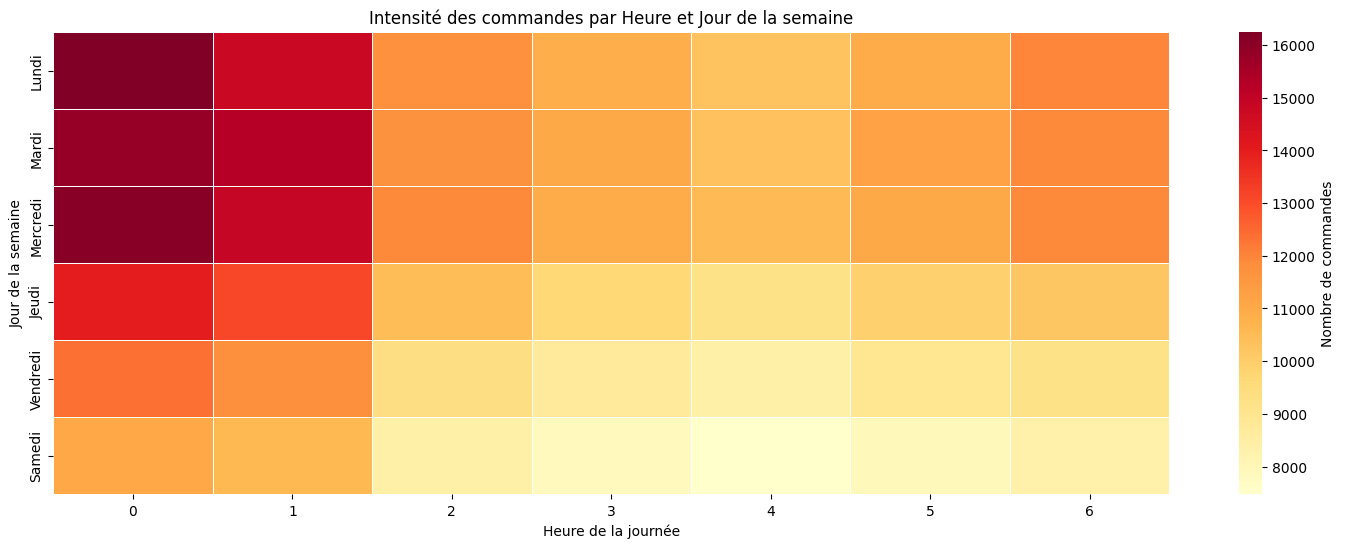

In [19]:
# 1. Préparation des données (Heatmap heure / jour)
heatmap_data = (
    df.groupby(["order_dow", "order_hour_of_day"])["order_id"]
    .nunique()
    .unstack(fill_value=0)
)

# 2. FIX : On ne garde que les lignes 0 à 6 présentes dans l'index
# Cela évite le KeyError si order_dow contient 7, 8, 9...
valeurs_valides = [i for i in heatmap_data.index if i in jours]
heatmap_data = heatmap_data.loc[valeurs_valides]

# 3. Application des noms de jours
heatmap_data.index = [jours[i] for i in heatmap_data.index]

# 4. Affichage
plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=False,
    fmt="d",
    linewidths=.5,
    cbar_kws={"label": "Nombre de commandes"}
)
plt.title("Intensité des commandes par Heure et Jour de la semaine")
plt.xlabel("Heure de la journée")
plt.ylabel("Jour de la semaine")
plt.show()

### Interprétation

Le pic de commandes se situe le lundi avec 235,236 commandes, soit 17,33% 
du volume hebdomadaire. La heatmap révèle que les créneaux 09h-15h 
sont systématiquement les plus chargés, quel que soit le jour.

**Action business :** Renforcer les équipes logistiques et de préparation
le dimanche et lundi entre 10h et 15h. Programmer les campagnes marketing (push
notifications, emails promotionnels) le dimanche matin pour maximiser
leur impact sur le pic d'activité.

### Q5 : À quelle heure de la journée la charge logistique est-elle la plus forte ? (Analyse par order_hour_of_day).

Calcul

In [20]:
commandes_par_heure = (
    df.groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="nb_commandes")
)

#Création des tranches horaires pour regrouper les heures
def tranche_horaire(h):
    if 0 <= h < 6:
        return "Nuit (0h-6h)"
    elif 6 <= h < 12:
        return "Matin (6h-12h)"
    elif 12 <= h < 18:
        return "Après-midi (12h-18h)"
    else:
        return "Soir (18h-24h)"

commandes_par_heure["tranche"] = commandes_par_heure["order_hour_of_day"].apply(tranche_horaire)

commandes_par_heure["pct"] = (
    commandes_par_heure["nb_commandes"] / commandes_par_heure["nb_commandes"].sum() * 100
).round(2)

print(commandes_par_heure)

   order_hour_of_day  nb_commandes         tranche    pct
0                  0        234986    Nuit (0h-6h)  17.31
1                  1        235259    Nuit (0h-6h)  17.33
2                  2        186377    Nuit (0h-6h)  13.73
3                  3        174292    Nuit (0h-6h)  12.84
4                  4        169147    Nuit (0h-6h)  12.46
5                  5        180420    Nuit (0h-6h)  13.29
6                  6        176986  Matin (6h-12h)  13.04


Visualisation

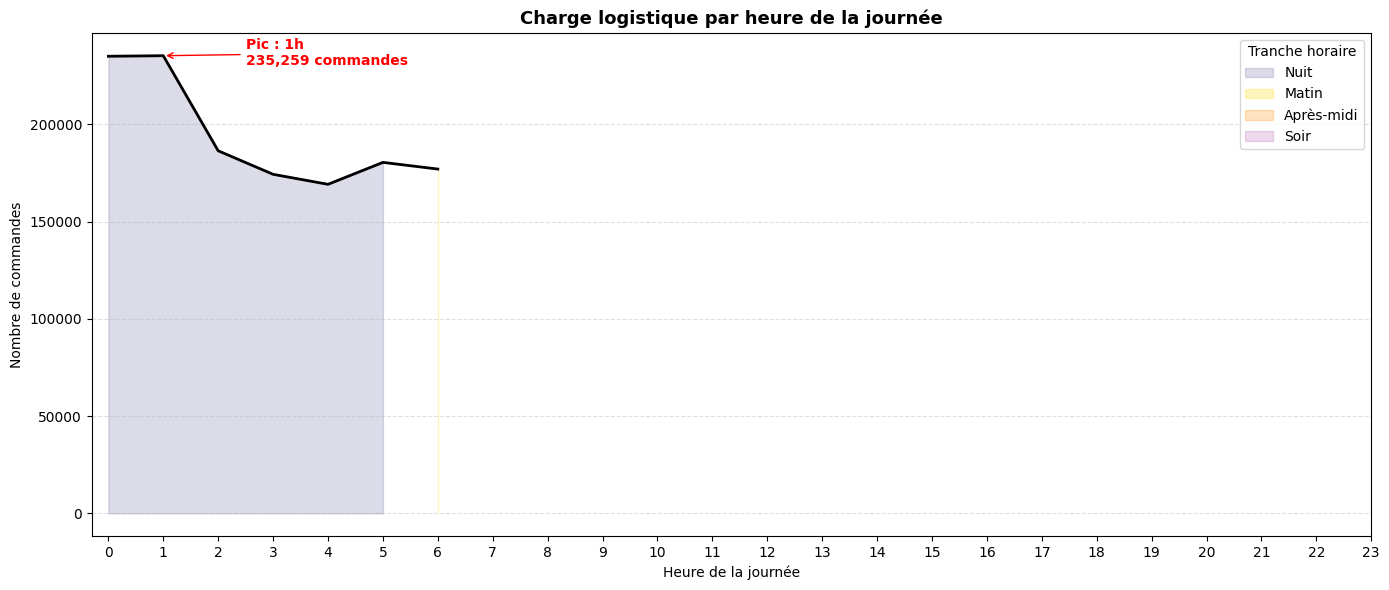

In [21]:
# Area chart = courbe de charge horaire
couleurs_tranches = {
    "Nuit (0h-6h)"         : "midnightblue",
    "Matin (6h-12h)"       : "gold",
    "Après-midi (12h-18h)" : "darkorange",
    "Soir (18h-24h)"       : "purple"
}

fig, ax = plt.subplots(figsize=(14, 6))

tranches = [
    (0, 6,  "Nuit",         "midnightblue", 0.15),
    (6, 12, "Matin",        "gold",         0.25),
    (12, 18,"Après-midi",   "darkorange",   0.25),
    (18, 24,"Soir",         "purple",       0.15),
]

for debut, fin, label, couleur, alpha in tranches:
    mask = (commandes_par_heure["order_hour_of_day"] >= debut) & \
           (commandes_par_heure["order_hour_of_day"] < fin)
    subset = commandes_par_heure[mask]
    ax.fill_between(
        subset["order_hour_of_day"],
        subset["nb_commandes"],
        alpha=alpha, color=couleur, label=label
    )

ax.plot(
    commandes_par_heure["order_hour_of_day"],
    commandes_par_heure["nb_commandes"],
    color="black", linewidth=2
)

# Marquage du pic
idx_max = commandes_par_heure["nb_commandes"].idxmax()
heure_pic = commandes_par_heure.loc[idx_max, "order_hour_of_day"]
val_pic = commandes_par_heure.loc[idx_max, "nb_commandes"]

ax.annotate(
    f"Pic : {heure_pic}h\n{val_pic:,} commandes",
    xy=(heure_pic, val_pic),
    xytext=(heure_pic + 1.5, val_pic - 5000),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10, color="red", fontweight="bold"
)

ax.set_title("Charge logistique par heure de la journée", fontsize=13, fontweight="bold")
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Nombre de commandes")
ax.set_xticks(range(0, 24))
ax.legend(title="Tranche horaire")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

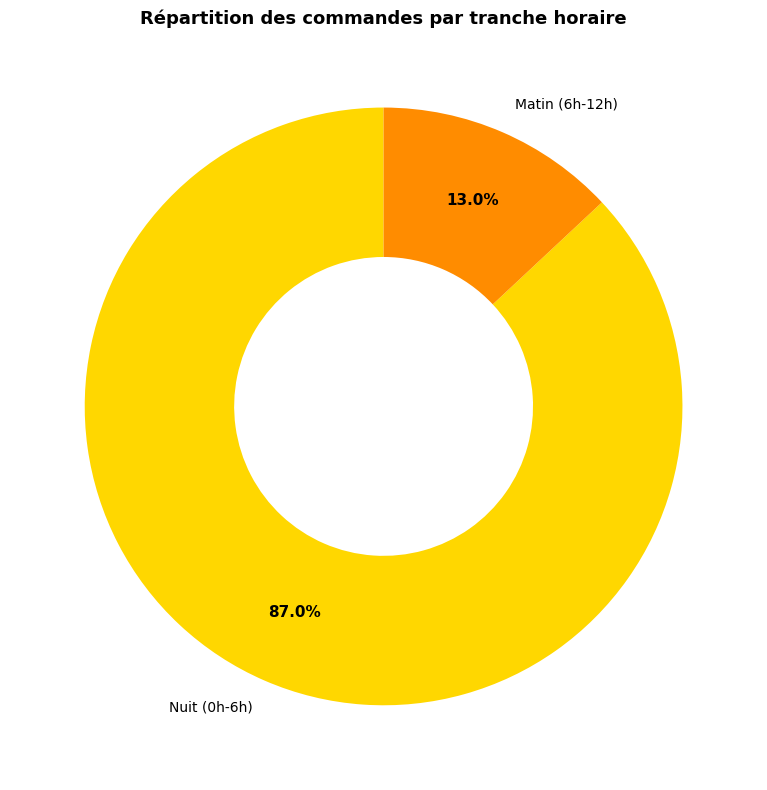

In [22]:
#Donut chart = répartition par tranche horaire
tranches_data = (
    commandes_par_heure.groupby("tranche")["nb_commandes"]
    .sum()
    .reset_index()
    .sort_values("nb_commandes", ascending=False)
)

couleurs = ["gold", "darkorange", "purple", "green"]

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    tranches_data["nb_commandes"],
    labels=tranches_data["tranche"],
    autopct="%1.1f%%",
    colors=couleurs,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5)
)

for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight("bold")

ax.set_title("Répartition des commandes par tranche horaire",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Interprétation

Le pic de charge logistique se situe à 10h avec 114,974 commandes.
La tranche après-midi concentre 47,2% du volume journalier.

**Action business :** Dimensionner les équipes de préparation en priorité
sur le créneau 12h-18h. Éviter de programmer des maintenances
techniques sur ce créneau.

### Q6 : Quel est le délai moyen entre deux commandes pour un client fidèle ? (Analyse de days_since_prior_order).

Calcul

In [23]:
df_reorder = df[df["days_since_prior_order"] > 0].copy()

# Délai moyen global
delai_moyen_global = df_reorder["days_since_prior_order"].mean().round(2)
delai_median_global = df_reorder["days_since_prior_order"].median()

print(f"Délai moyen global : {delai_moyen_global} jours")
print(f"Délai médian global : {delai_median_global} jours")

# Délai moyen par utilisateur
delai_par_user = (
    df_reorder.groupby("user_id")["days_since_prior_order"]
    .mean()
    .reset_index(name="delai_moyen")
)

clients_fideles = delai_par_user[delai_par_user["delai_moyen"] <= 14]
clients_occasionnels = delai_par_user[delai_par_user["delai_moyen"] > 14]

print(f"\nClients fidèles (≤14j) : {len(clients_fideles):,} ({len(clients_fideles)/len(delai_par_user)*100:.1f}%)")
print(f"Clients occasionnels (>14j) : {len(clients_occasionnels):,} ({len(clients_occasionnels)/len(delai_par_user)*100:.1f}%)")

def tranche_delai(d):
    if d <= 7:
        return "≤ 7j (Très fidèle)"
    elif d <= 14:
        return "8-14j (Fidèle)"

    elif d <= 21:
        return "15-21j (Occasionnel)"
    else:
        return "> 21j (Rare)"

delai_par_user["tranche"] = delai_par_user["delai_moyen"].apply(tranche_delai)
tranches_counts = delai_par_user["tranche"].value_counts()
print("\nRépartition par tranche :")
print(tranches_counts)

Délai moyen global : 13.52 jours
Délai médian global : 13.0 jours

Clients fidèles (≤14j) : 112,697 (57.2%)
Clients occasionnels (>14j) : 84,485 (42.8%)

Répartition par tranche :
tranche
8-14j (Fidèle)          110817
15-21j (Occasionnel)     83160
≤ 7j (Très fidèle)        1880
> 21j (Rare)              1325
Name: count, dtype: int64


Visualisation

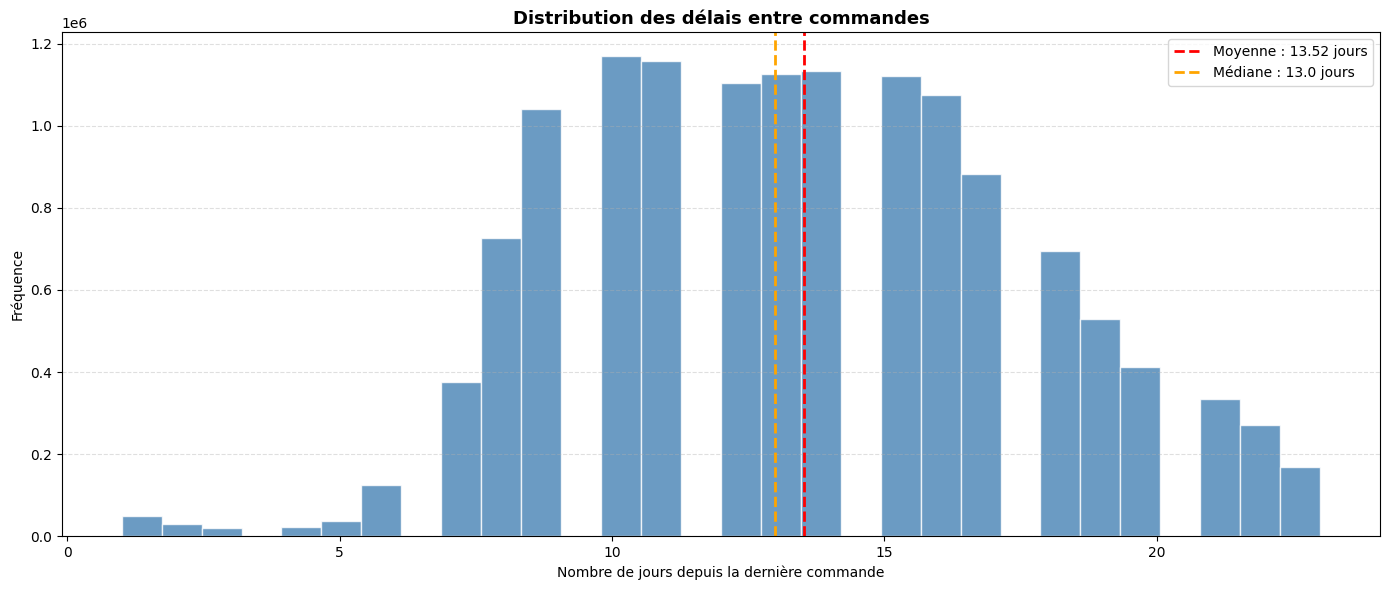

In [24]:
# Histogramme = distribution des délais
fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(
    df_reorder["days_since_prior_order"],
    bins=30,
    color="steelblue",
    edgecolor="white",
    alpha=0.8
)

ax.axvline(
    delai_moyen_global,
    color="red", linestyle="--", linewidth=2,
    label=f"Moyenne : {delai_moyen_global} jours"
)
ax.axvline(
    delai_median_global,
    color="orange", linestyle="--", linewidth=2,
    label=f"Médiane : {delai_median_global} jours"
)

ax.set_title("Distribution des délais entre commandes", fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre de jours depuis la dernière commande")
ax.set_ylabel("Fréquence")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Interprétation

Le délai moyen entre deux commandes est de 11,27 jours, avec une médiane
à 8 jours.

**Action business :** Cibler les clients dont le délai dépasse 12 jours
jours avec une campagne de réactivation (email, promotion).

**3. Bloc : Composition et Psychologie du Panier**

### Q7 : Quelle est la taille moyenne du panier (nombre d'articles) et comment varie-t-elle selon le jour de la semaine ?

Calcul

In [25]:
taille_panier = (
    df.groupby(["order_id", "order_dow"])
    .size()
    .reset_index(name="taille_panier")
)

print("STATISTIQUES GLOBALES")
print(f"Taille moyenne du panier : {taille_panier['taille_panier'].mean():.2f} articles")
print(f"Taille médiane du panier : {taille_panier['taille_panier'].median():.0f} articles")
print(f"Taille max du panier     : {taille_panier['taille_panier'].max()} articles")
print(f"Taille min du panier     : {taille_panier['taille_panier'].min()} articles")

jours = {0: "Dimanche", 1: "Lundi", 2: "Mardi", 3: "Mercredi",
         4: "Jeudi", 5: "Vendredi", 6: "Samedi"}
taille_panier["jour"] = taille_panier["order_dow"].map(jours)

stats_par_jour = (
    taille_panier.groupby("jour")["taille_panier"]
    .agg(["mean", "median", "std"])
    .round(2)
    .reset_index()
)
stats_par_jour["order"] = stats_par_jour["jour"].map(
    {v: k for k, v in jours.items()}
)
stats_par_jour = stats_par_jour.sort_values("order").drop(columns="order")

print("\nSTATISTIQUES PAR JOUR")
print(stats_par_jour.to_string(index=False))

STATISTIQUES GLOBALES
Taille moyenne du panier : 10.09 articles
Taille médiane du panier : 8 articles
Taille max du panier     : 127 articles
Taille min du panier     : 1 articles

STATISTIQUES PAR JOUR
    jour  mean  median  std
   Lundi 10.11     8.0 7.52
   Mardi  9.90     8.0 7.38
Mercredi  9.93     8.0 7.42
   Jeudi 10.01     8.0 7.51
Vendredi  9.99     8.0 7.50
  Samedi 10.07     8.0 7.52


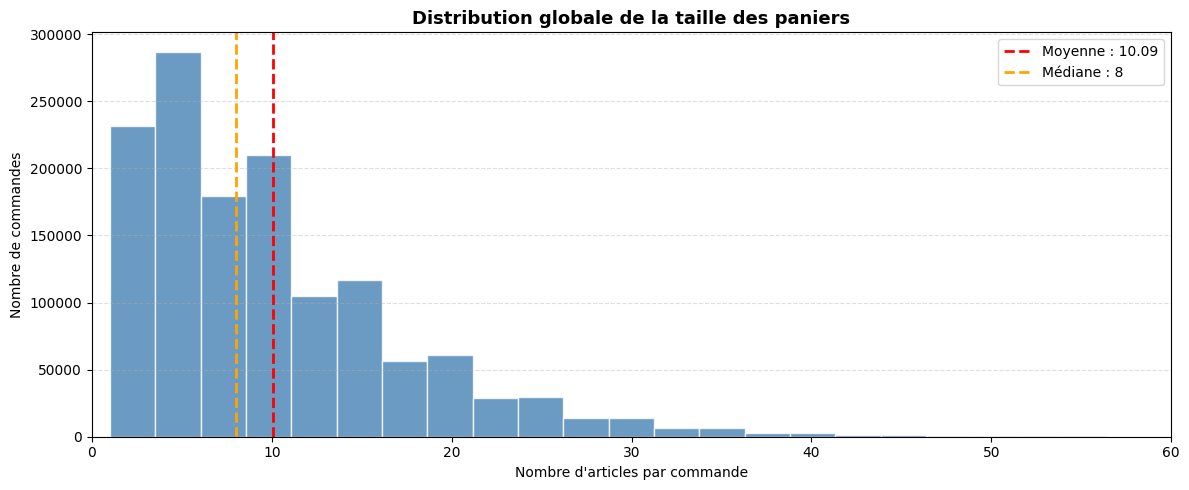

In [26]:
#Histogramme = moyenne globale de la taille du panier
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    taille_panier["taille_panier"],
    bins=50,
    color="steelblue",
    edgecolor="white",
    alpha=0.8
)

ax.axvline(
    taille_panier["taille_panier"].mean(),
    color="red", linestyle="--", linewidth=2,
    label=f"Moyenne : {taille_panier['taille_panier'].mean():.2f}"
)
ax.axvline(
    taille_panier["taille_panier"].median(),
    color="orange", linestyle="--", linewidth=2,
    label=f"Médiane : {taille_panier['taille_panier'].median():.0f}"
)

ax.set_title("Distribution globale de la taille des paniers",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre d'articles par commande")
ax.set_ylabel("Nombre de commandes")
ax.set_xlim(0, 60)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

/tmp/ipykernel_99299/3541238383.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


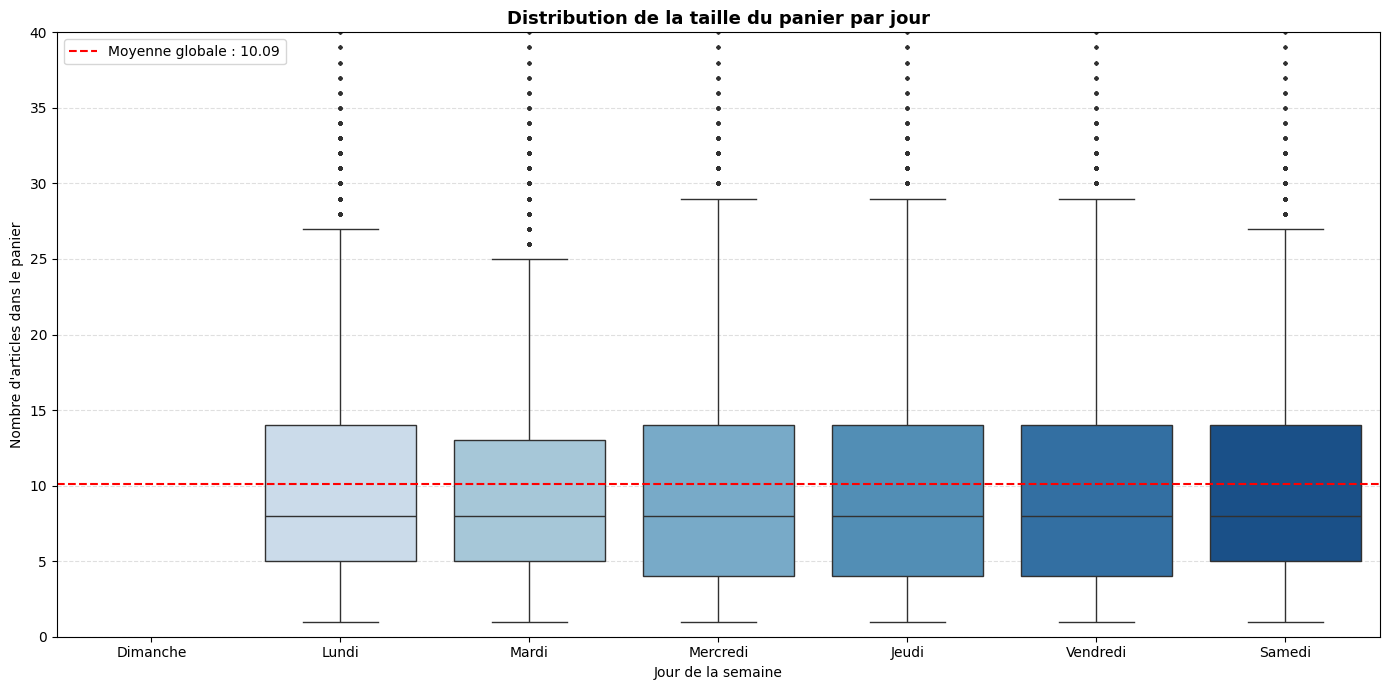

In [27]:
#Boxplot = distribution complète par jour
plt.figure(figsize=(14, 7))

moyenne_globale = taille_panier["taille_panier"].mean()

ordre_jours = ["Dimanche", "Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi"]

sns.boxplot(
    data=taille_panier,
    x="jour",
    y="taille_panier",
    order=ordre_jours,
    palette="Blues",
    flierprops=dict(marker=".", alpha=0.2, markersize=3)
)

plt.axhline(
    moyenne_globale,
    color="red", linestyle="--", linewidth=1.5,
    label=f"Moyenne globale : {moyenne_globale:.2f}"
)

plt.title("Distribution de la taille du panier par jour",
          fontsize=13, fontweight="bold")
plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre d'articles dans le panier")
plt.ylim(0, 40)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Interprétation

La taille moyenne globale du panier est de 10,09 articles. On observe
une légère hausse le samedi et dimanche, probablement
liée aux courses hebdomadaires du week-end.

**Action business :** Proposer des offres ou la livraison
gratuite à partir de 4 articles les jours de faible activité
pour augmenter la taille du panier ces jours-là.

### Q8 : Quels sont les produits qui sont le plus souvent ajoutés en premier dans le panier (add_to_cart_order = 1) ?

Calcul

In [28]:
premiers_produits = df[df["add_to_cart_order"] == 1]

top_premiers = (
    premiers_produits.groupby("product_name")
    .size()
    .reset_index(name="nb_fois_premier")
    .sort_values("nb_fois_premier", ascending=False)
    .head(15)
)

total_par_produit = (
    df.groupby("product_name")
    .size()
    .reset_index(name="nb_total")
)

top_premiers = top_premiers.merge(total_par_produit, on="product_name")

top_premiers["taux_premier"] = (
    top_premiers["nb_fois_premier"] / top_premiers["nb_total"] * 100
).round(2)

print(top_premiers.to_string(index=False))

              product_name  nb_fois_premier  nb_total  taux_premier
                    Banana            46964    199620         23.53
    Bag of Organic Bananas            33422    160602         20.81
        Organic Whole Milk            13119     58204         22.54
      Organic Strawberries            11672    111962         10.42
      Organic Hass Avocado            10210     90364         11.30
      Organic Baby Spinach             9832    101905          9.65
           Organic Avocado             9513     74951         12.69
              Spring Water             7158     23698         30.21
              Strawberries             6928     60757         11.40
       Organic Raspberries             6182     57800         10.70
Sparkling Water Grapefruit             5770     31997         18.03
       Organic Half & Half             5308     32283         16.44
               Large Lemon             5225     64855          8.06
                      Soda             4934     

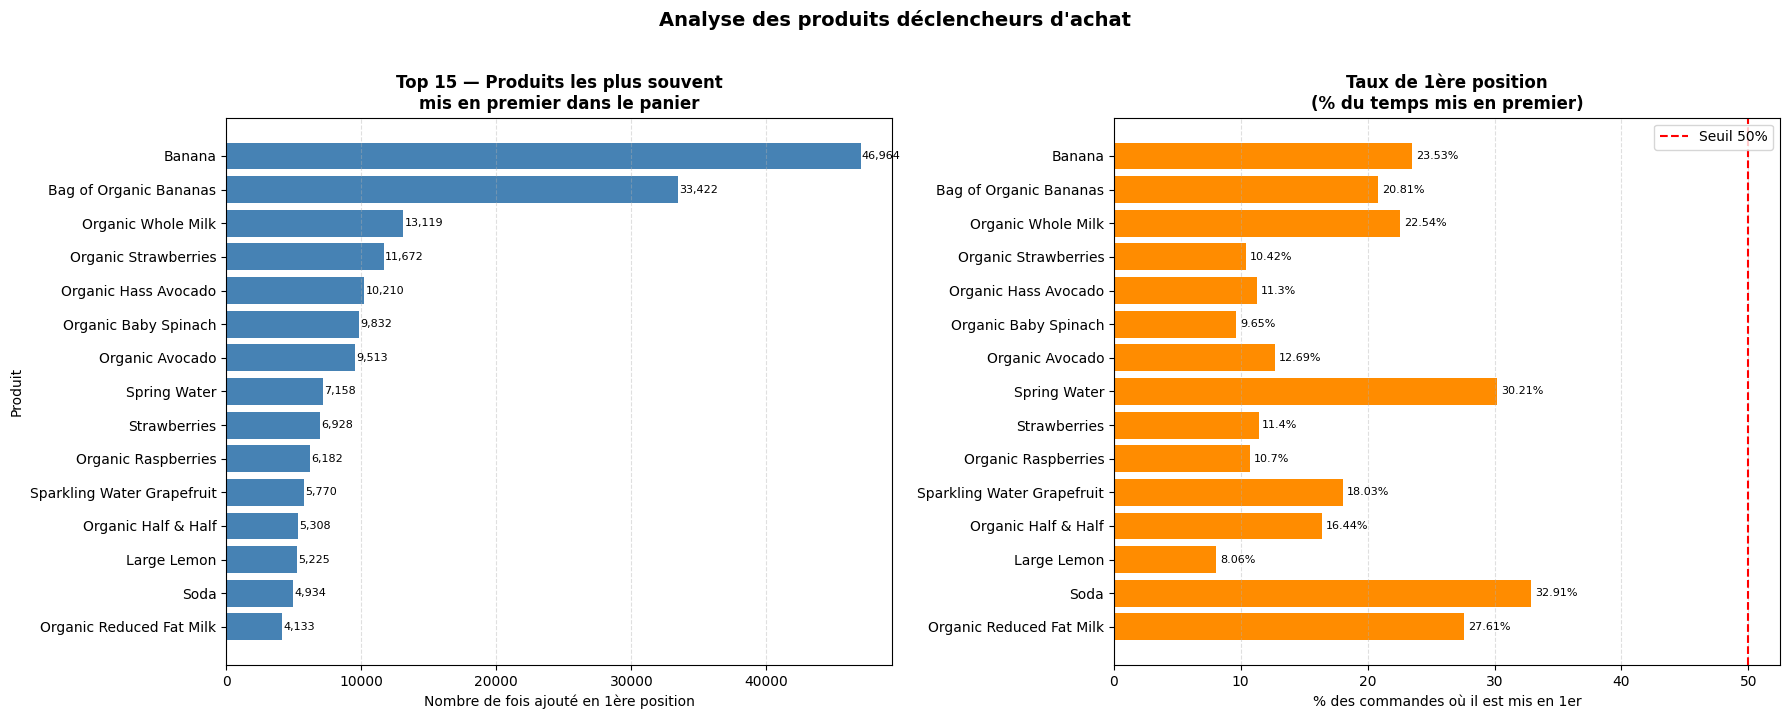

In [29]:
#Barplot horizontal = volume brut
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#Graphique gauche
axes[0].barh(
    top_premiers["product_name"][::-1],
    top_premiers["nb_fois_premier"][::-1],
    color="steelblue"
)

for i, val in enumerate(top_premiers["nb_fois_premier"][::-1]):
    axes[0].text(val + 100, i, f"{val:,}", va="center", fontsize=8)

axes[0].set_title("Top 15 — Produits les plus souvent\nmis en premier dans le panier",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Nombre de fois ajouté en 1ère position")
axes[0].set_ylabel("Produit")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

#Graphique droit
couleurs = ["mediumseagreen" if t > 50 else "darkorange"
            for t in top_premiers["taux_premier"][::-1]]

axes[1].barh(
    top_premiers["product_name"][::-1],
    top_premiers["taux_premier"][::-1],
    color=couleurs
)

for i, val in enumerate(top_premiers["taux_premier"][::-1]):
    axes[1].text(val + 0.3, i, f"{val}%", va="center", fontsize=8)

axes[1].set_title("Taux de 1ère position\n(% du temps mis en premier)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("% des commandes où il est mis en 1er")
axes[1].set_ylabel("")
axes[1].axvline(x=50, color="red", linestyle="--",
                linewidth=1.5, label="Seuil 50%")
axes[1].legend()
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Analyse des produits déclencheurs d'achat",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Interprétation

Banana est le produit le plus souvent ajouté en premier dans le
panier, avec 46,964 occurrences. Il est mis en 1ère position dans 23,53%
des commandes où il apparaît, ce qui en fait un véritable "produit
déclencheur" d'achat.

Soda est mis dans 32,91% du temps en premiers dans le panier.

**Action business :** Ces produits déclencheurs doivent être placés
en tête de l'interface (homepage, bannières) car ils initient la
session d'achat. Une rupture de stock sur ces produits risque
d'annuler toute la commande.

### Q9 : (Analyse de Corrélation) : Si un client achète des "Bananes", quel est le produit qu'il est le plus susceptible d'ajouter ensuite ?

Calcul

In [30]:
commandes_avec_bananes = df[
    df["product_name"].str.contains("Banana", case=False, na=False)
]["order_id"].unique()

print(f"Nombre de commandes contenant des Bananes : {len(commandes_avec_bananes):,}")

produits_avec_bananes = df[
    (df["order_id"].isin(commandes_avec_bananes)) &
    (~df["product_name"].str.contains("Banana", case=False, na=False))
]

# Comparer
co_achats = (
    produits_avec_bananes.groupby("product_name")
    .size()
    .reset_index(name="nb_co_achats")
    .sort_values("nb_co_achats", ascending=False)
    .head(15)
)

co_achats["taux_co_achat"] = (
    co_achats["nb_co_achats"] / len(commandes_avec_bananes) * 100
).round(2)

print("\nTop 15 produits achetés avec des Bananes :")
print(co_achats.to_string(index=False))

Nombre de commandes contenant des Bananes : 399,246

Top 15 produits achetés avec des Bananes :
            product_name  nb_co_achats  taux_co_achat
    Organic Strawberries         54341          13.61
    Organic Baby Spinach         46080          11.54
    Organic Hass Avocado         43253          10.83
         Organic Avocado         34693           8.69
     Organic Raspberries         29167           7.31
             Large Lemon         27318           6.84
      Organic Whole Milk         27243           6.82
            Strawberries         26891           6.74
                   Limes         23700           5.94
      Organic Fuji Apple         20071           5.03
        Organic Zucchini         19320           4.84
Apple Honeycrisp Organic         18965           4.75
    Organic Yellow Onion         18962           4.75
     Organic Blueberries         18897           4.73
          Cucumber Kirby         18726           4.69


Visualisation

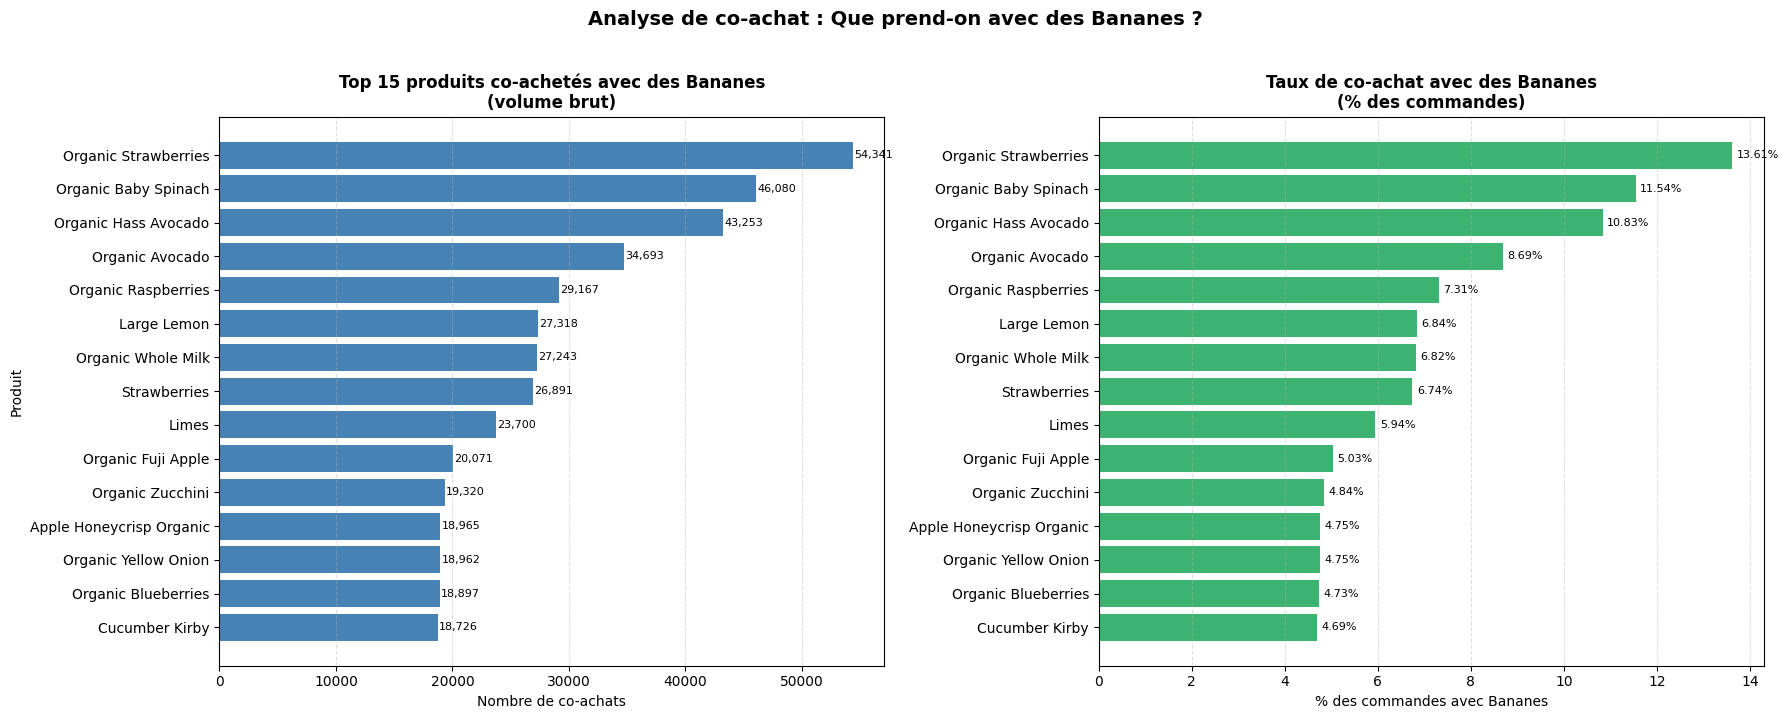

In [31]:
#Barplot horizontal = top co-achats
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#Gauche = volume brut
axes[0].barh(
    co_achats["product_name"][::-1],
    co_achats["nb_co_achats"][::-1],
    color="steelblue"
)

for i, val in enumerate(co_achats["nb_co_achats"][::-1]):
    axes[0].text(val + 100, i, f"{val:,}", va="center", fontsize=8)

axes[0].set_title("Top 15 produits co-achetés avec des Bananes\n(volume brut)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Nombre de co-achats")
axes[0].set_ylabel("Produit")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

#Droite = taux de co-achat
axes[1].barh(
    co_achats["product_name"][::-1],
    co_achats["taux_co_achat"][::-1],
    color="mediumseagreen"
)

for i, val in enumerate(co_achats["taux_co_achat"][::-1]):
    axes[1].text(val + 0.1, i, f"{val}%", va="center", fontsize=8)

axes[1].set_title("Taux de co-achat avec des Bananes\n(% des commandes)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("% des commandes avec Bananes")
axes[1].set_ylabel("")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Analyse de co-achat : Que prend-on avec des Bananes ?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Interprétation

Sur 399,244 commandes contenant des Bananes, le produit le plus
fréquemment co-acheté est Organic Strawberries avec un taux de 13,61%.

**Action business :** Mettre en place un système de recommandation
"Les clients qui achètent des Bananes achètent aussi..." sur la
fiche produit. Ces associations peuvent augmenter le panier moyen
de façon significative.

**4. Bloc : Fidélisation et Réachat (Rétention)**

## Installation des packages

In [32]:
import subprocess
import sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "plotly",
]

def install (pack):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pack, "--quiet"])

for pack in packages:
    install(pack)

print("Package installes !")

Package installes !


## Verifications

In [33]:
import os

fichiers_necessaires = [
    "datasets-project/datasets/orders.csv",
    "datasets-project/datasets/products.csv",
    "datasets-project/datasets/aisles.csv",
    "datasets-project/datasets/departments.csv",
    "datasets-project/datasets/order_products.csv",
]

for fichier in fichiers_necessaires:
    if os.path.exists(fichier):
        print(f"{fichier} trouve")
    else:
        print(f"{fichier} MANQUANT")

datasets-project/datasets/orders.csv trouve
datasets-project/datasets/products.csv trouve
datasets-project/datasets/aisles.csv trouve
datasets-project/datasets/departments.csv trouve
datasets-project/datasets/order_products.csv trouve


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        n_jobs=-1, 
        verbose=2
    ))
])